# Testing: Color Classification

In [1]:
from color import PokemonColorDetectorHSV

detector = PokemonColorDetectorHSV()
colors, counts = detector.detect_colors("dataset/images/train/Abra_Abra_0.png", 5000, 0.1)
colors

{'Brown', 'Yellow'}

## Testing color classification on Rendered Images

In [4]:
import os

def load_images(image_dir):
    images = []
    for fname in os.listdir(image_dir):
        if fname.lower().endswith(".png"):
            pokemon = fname.split("_")[0].lower()
            images.append((fname, pokemon))
    return images

In [3]:
def detect_colors_for_images(image_dir):
    results = {}

    for fname, pokemon in load_images(image_dir):
        path = os.path.join(image_dir, fname)
        colors, counts = detector.detect_colors(path, min_ratio=0.25)

        if colors:  # ignore empty detections
            results[fname] = {
                "pokemon": pokemon,
                "colors": list(colors),
            }

    return results

In [8]:
from query import PokemonQueryEngine

engine = PokemonQueryEngine("/home/khurbii/Documents/UUM_S1/KDE/Excercises/Project/data/ontology.ttl", "/home/khurbii/Documents/UUM_S1/KDE/Excercises/Project/data/entities.ttl")
images = detect_colors_for_images("dataset/images/val/")

results = 0
for result in images.items():
    pokemon = result[1]["pokemon"]
    colors = result[1]["colors"]
    check = all([engine.has_color(pokemon, color) for color in colors])

    results += int(check)

In [10]:
results/len(images)

0.3333333333333333

# Testing: Query Engine

In [11]:
from query import PokemonQueryEngine

engine = PokemonQueryEngine("/home/khurbii/Documents/UUM_S1/KDE/Excercises/Project/data/ontology.ttl", "/home/khurbii/Documents/UUM_S1/KDE/Excercises/Project/data/entities.ttl")
engine.find_with_all(["Legs", "Arms", "DragonWings"], ["Red"])

{'charizard'}

# Testing: Attribute Detection

In [14]:
from detection import YOLOPredictor

detector = YOLOPredictor("result/yolo/best.pt")

In [21]:
result = detector.predict("dataset/images/val/Arcanine_Arcanine_144.png", conf=0.45)
print(result[0])


image 1/1 /home/khurbii/Documents/UUM_S1/KDE/Excercises/KDE/KDE_Project_Group1/visual/dataset/images/val/Arcanine_Arcanine_144.png: 640x640 1 Head, 2 Feets, 1 Eye, 1 Mouth, 1 Ear, 1 Tail, 4 Body Symbols, 1 Mane, 1 Hair, 1 Main Body, 161.9ms
Speed: 5.6ms preprocess, 161.9ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
[{'label': 'Tail', 'class_id': 13, 'confidence': 0.994717538356781, 'bbox_xyxy': [256.0447692871094, 344.53826904296875, 485.3223571777344, 606.4017333984375]}, {'label': 'Mane', 'class_id': 38, 'confidence': 0.9772816896438599, 'bbox_xyxy': [468.6177673339844, 407.79168701171875, 733.7195434570312, 678.3844604492188]}, {'label': 'Main Body', 'class_id': 41, 'confidence': 0.9530056118965149, 'bbox_xyxy': [231.29598999023438, 426.0140686035156, 740.7791137695312, 808.76318359375]}, {'label': 'Feet', 'class_id': 5, 'confidence': 0.9478468894958496, 'bbox_xyxy': [300.99261474609375, 707.2840576171875, 729.9761352539062, 803.5881958007812]}, {'label': 'Ear

# Testing: Node Embedding

In [111]:
from embedding import PokemonRDF2VecModel

model = PokemonRDF2VecModel([
        "/home/khurbii/Documents/UUM_S1/KDE/Excercises/Project/data/ontology.ttl"
    ], [
        "/home/khurbii/Documents/UUM_S1/KDE/Excercises/Project/data/entities.ttl"
    ])

Triples loaded: 1784
After reasoning: 2480


In [112]:
model.train()

Pokémon count: 151
Training complete.


In [113]:
model.predict({""
"Yellow" : 1, 
"Arms" : 0.6, 
"BodySymbols" : 0.5, 
"Legs" : 0.8, 
"Tail" : 1
}, top_k=10)

[('https://pokemonkg.org/instance/pokemon#staryu', np.float32(0.38008916)),
 ('https://pokemonkg.org/instance/pokemon#starmie', np.float32(0.35903242)),
 ('https://pokemonkg.org/instance/pokemon#onix', np.float32(0.34131783)),
 ('https://pokemonkg.org/instance/pokemon#seadra', np.float32(0.33807403)),
 ('https://pokemonkg.org/instance/pokemon#poliwag', np.float32(0.32812718)),
 ('https://pokemonkg.org/instance/pokemon#porygon', np.float32(0.29722401)),
 ('https://pokemonkg.org/instance/pokemon#parasect', np.float32(0.29674974)),
 ('https://pokemonkg.org/instance/pokemon#zapdos', np.float32(0.29195684)),
 ('https://pokemonkg.org/instance/pokemon#lickitung', np.float32(0.2905892)),
 ('https://pokemonkg.org/instance/pokemon#kabuto', np.float32(0.27517593))]

## Testing Embedding Results

In [114]:
import random
from rdflib import URIRef

def hit_at_k(model, queries, k=10):
    hits = []

    for true_pokemon, query in queries:
        ranked = model.predict(query, top_k=k)
        retrieved = {p for p, _ in ranked}

        hits.append(int(true_pokemon in retrieved))

    return sum(hits) / len(hits)



In [115]:
def generate_queries(model, predicates, n_attrs=3):
    queries = []

    for p in model.entities:
        attrs = []
        for pred in predicates:
            attrs.extend(list(model.graph.objects(URIRef(p), pred)))

        if len(attrs) >= n_attrs:
            chosen = random.sample(attrs, n_attrs)
            query = {a.split("#")[-1]: 1.0 for a in map(str, chosen)}
            queries.append((p, query))

    return queries


In [123]:
import random
random.seed(10)

results = []

N = [1, 3, 5]
K = [1, 5, 10, 20, 25]

predicates = [
    model.onto_ns.hasColor,
    model.onto_ns.hasAttribute
]

for n in N:
    queries = generate_queries(model, predicates, n_attrs=n)
    hit_rates = [hit_at_k(model, queries, k=k) for k in K]
    results.append(hit_rates)


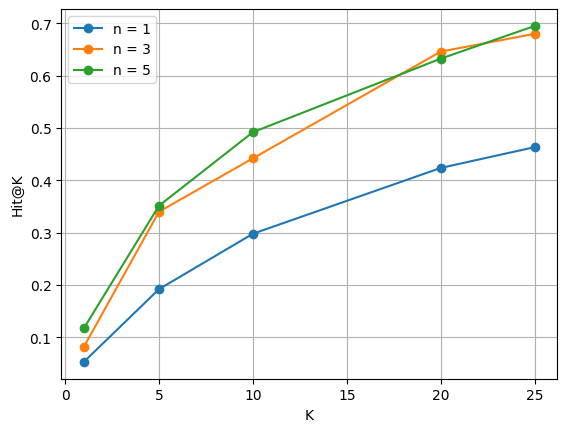

In [126]:
import matplotlib.pyplot as plt

plt.figure()

for i, n in enumerate(N):
    plt.plot(K, results[i], marker='o', label=f'n = {n}')

plt.xlabel('K')
plt.ylabel('Hit@K')
# plt.title('Hit@K given N features')
plt.legend()
plt.grid(True)
plt.show()
